In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
import urllib.request

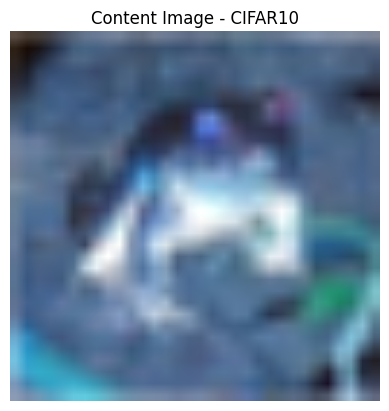

In [8]:
(x_train, y_train), (_, _) = cifar10.load_data()

content_image_raw = x_train[0]

content_image_raw = tf.image.resize(content_image_raw, (224,224)).numpy()
content_image_raw = np.expand_dims(content_image_raw, axis=0)
content_image = preprocess_input(content_image_raw)

plt.imshow((content_image[0]+128)/255)
plt.title("Content Image - CIFAR10")
plt.axis("off")
plt.show()

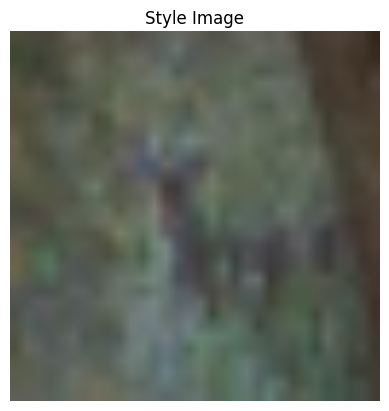

In [10]:
style_image_raw = x_train[10]

style_image_raw = tf.image.resize(style_image_raw, (224,224)).numpy()
style_image_raw = np.expand_dims(style_image_raw, axis=0)
style_image = preprocess_input(style_image_raw)

plt.imshow((style_image[0]+128)/255)
plt.title("Style Image")
plt.axis("off")
plt.show()

In [11]:
vgg = VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
content_layers = ['block5_conv2']

style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

outputs = [vgg.get_layer(name).output for name in content_layers + style_layers]
model = Model([vgg.input], outputs)
model.trainable = False

In [13]:
def gram_matrix(tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', tensor, tensor)
    shape = tf.shape(tensor)
    num_locations = tf.cast(shape[1]*shape[2], tf.float32)
    return result / num_locations

def get_features(img):
    outputs = model(img)
    content_features = outputs[:len(content_layers)]
    style_features = outputs[len(content_layers):]
    return content_features, style_features

In [14]:
content_targets, _ = get_features(content_image)
_, style_targets = get_features(style_image)

/usr/local/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [15]:
content_weight = 1e4
style_weight = 1e-2

def content_loss(base, target):
    return tf.reduce_mean(tf.square(base - target))

def style_loss(base, target):
    gram_base = gram_matrix(base)
    gram_target = gram_matrix(target)
    return tf.reduce_mean(tf.square(gram_base - gram_target))

def total_loss(outputs):
    content_outputs = outputs[:len(content_layers)]
    style_outputs = outputs[len(content_layers):]

    c_loss = tf.add_n([
        content_loss(content_outputs[i], content_targets[i])
        for i in range(len(content_layers))
    ])

    s_loss = tf.add_n([
        style_loss(style_outputs[i], style_targets[i])
        for i in range(len(style_layers))
    ])

    return content_weight*c_loss + style_weight*s_loss

In [16]:
generated_image = tf.Variable(content_image, dtype=tf.float32)
optimizer = tf.keras.optimizers.Adam(learning_rate=5.0)

In [17]:
@tf.function
def train_step():
    with tf.GradientTape() as tape:
        outputs = model(generated_image)
        loss = total_loss(outputs)

    grads = tape.gradient(loss, generated_image)
    optimizer.apply_gradients([(grads, generated_image)])
    generated_image.assign(tf.clip_by_value(generated_image, -128.0, 128.0))
    return loss

In [18]:
epochs = 200

for i in range(epochs):
    loss = train_step()
    if i % 20 == 0:
        print("Step:", i, "Loss:", loss.numpy())

Step: 0 Loss: 1.7007328e+08
Step: 20 Loss: 4.345251e+07
Step: 40 Loss: 1.9104736e+07
Step: 60 Loss: 1.1503048e+07
Step: 80 Loss: 8.240299e+06
Step: 100 Loss: 6.473947e+06
Step: 120 Loss: 5.435053e+06
Step: 140 Loss: 4.761649e+06
Step: 160 Loss: 4.290286e+06
Step: 180 Loss: 3.9646072e+06


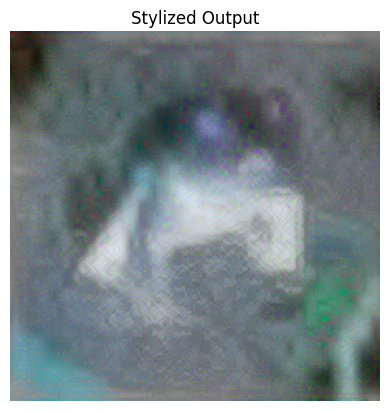

In [19]:
final_img = generated_image.numpy()[0]
final_img = (final_img + 128)/255
final_img = np.clip(final_img,0,1)

plt.imshow(final_img)
plt.title("Stylized Output")
plt.axis("off")
plt.show()